In [1]:
#this script is setup for using the 0.25 RYF wombatlite MOM6 for boundary and initial conditions - some parts are still a bit messy! 
import xgcm

from xgcm import transform

import xarray as xr
import os
import subprocess
import matplotlib.pyplot as plt
from pathlib import Path
from dask.distributed import Client
import dask
import numpy as np
import intake
import glob
import pandas as pd

#this is needed until PR on regional mom6for using C grid data goes through on gdata xp65 envs 
import sys
sys.path.insert(0,"/home/156/ee8016/rmom6/regional-mom6-fixbgc/regional-mom6") 
import regional_mom6 as rmom6

print("using regional-mom6 version " + rmom6.__version__)
#import regional_mom6 as rmom6



using regional-mom6 version unknown


In [2]:
setup_unprocessed=True
setup_bathy=True
setup_tides=True
setup_regridded=True

In [3]:

n_workers = 4         
threads_per_worker = 2
memory_limit = "90GB"     

client = Client(threads_per_worker = threads_per_worker, n_workers=n_workers, memory_limit=memory_limit)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 8,Total memory: 335.28 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41531,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35935,Total threads: 2
Dashboard: /proxy/45679/status,Memory: 83.82 GiB
Nanny: tcp://127.0.0.1:32961,


In [4]:


scratch = subprocess.run("echo /scratch/nm03/$USER", shell=True, capture_output=True, text=True).stdout.strip()
gdata = subprocess.run("echo /g/data/nm03/$USER", shell=True, capture_output=True, text=True).stdout.strip()
home = subprocess.run("echo ~", shell=True, capture_output=True, text=True).stdout.strip()

# this will be the name for directories
expt_name = "NWshelf_01_IAF" 
latitude_extent = [-24, -6]
longitude_extent = [111, 130]

longitude_extent= [lon - 360 if lon > 50 else lon for lon in longitude_extent]
date_range = ["2016-01-15", "2024-01-01"]        
#date_range = ["1919-01-01", "1921-01-01"]        

## Place where all the input files go
input_dir = f"{scratch}/regional_mom6_configs/{expt_name}/"

## Directory where we'll be running the experiment from
run_dir = f"{home}/mom6_rundirs/{expt_name}/"

## Directory where the compiled FRE tools are located (needed to construct mask tables)
fre_tools_dir = "/g/data/ik11/mom6_tools/tools"

## Directory where ocean model cut-outs go before processing
tmp_dir = f"{gdata}/{expt_name}"

## if directories don't exist, create them
for path in (run_dir, tmp_dir, input_dir):
    os.makedirs(str(path), exist_ok=True)




In [5]:
%%time
#this now goes to 2023
def interfaces_to_centres(da_zi):
    """
    Average interface quantities to get centre quantities
    """
    zl = (da_zi.zi.values[:-1] + da_zi.zi.values[1:]) / 2
    da_zi = da_zi.rename(zi="zl")
    lowers = da_zi.isel(zl=slice(1,None)).assign_coords({"zl": zl})
    uppers = da_zi.isel(zl=slice(None,-1)).assign_coords({"zl": zl})
    da_zl = (lowers + uppers) / 2
    da_zl.zl.attrs["axis"] = "Z"
    return da_zl


date_range_s = slice("2016-01", "2023-12")
if setup_unprocessed:
    def preprocess(ds):
        return ds.sel(time=date_range_s, drop=True)
        
    buffer=0.6
    wombatlitepath='/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/'
    
    var3d=['no3','uo+z','vo+z','alk','fe','no3','o2','phy', 'zoo', 'det', 'caco3', 'pchl', 'phyfe', 'zoofe', 'detfe', 'dic','dicp', 'dicr','so+z','thetao+z','e']
    
    var2d=['zos','det_sediment','caco3_sediment','detfe_sediment']
    
    datasets3d = []
    for var_name in var3d:
        #print(var_name)
        file_path = os.path.join(wombatlitepath,"output0**", f"access-om3.mom6.3d.{var_name}.1mon.mean.*.nc")
        files = sorted(glob.glob(file_path))
        ds = xr.open_mfdataset(files,preprocess=preprocess,combine="nested",
        concat_dim="time",chunks={"time": 1, "z_l": -1, "zl": -1, "zi": -1, "z_i": -1, "yh": 100, "xh": 100,"yq": 100, "xq": 100}
    )   
        datasets3d.append(ds)
    access_om2_input3d = xr.merge(datasets3d, join="override", compat="override")
    
    datasets2d = []
    for var_name in var2d:
        #print(var_name)
        file_path = os.path.join(wombatlitepath,"output0**", f"access-om3.mom6.2d.{var_name}.1mon.mean.*.nc")
        files = sorted(glob.glob(file_path))
        ds = xr.open_mfdataset(files,preprocess=preprocess,combine="nested",
        concat_dim="time",chunks={"time": 1, "yh": 100, "xh": 100,"yq": 100, "xq": 100})   
        datasets2d.append(ds)
    access_om2_input2d = xr.merge(datasets2d, join="override", compat="override")
    
    access_om2_input = xr.merge([access_om2_input3d, access_om2_input2d], join="override", compat="override")
    
    access_om2_input = access_om2_input.sel(
            yh = slice(latitude_extent[0] - buffer, latitude_extent[1] + buffer),
           yq = slice(latitude_extent[0] - buffer, latitude_extent[1] + buffer))
    
    #these vars weren't saved as outputs but are needed as inputs
    access_om2_input["detbury"] = xr.zeros_like(access_om2_input["no3"])
    access_om2_input["caco3bury"] = xr.zeros_like(access_om2_input["no3"])
    
    access_om2_input = access_om2_input.drop_vars(
        ["average_T1", "average_T2", "average_DT", "time_bnds","nv"]
    )

    e_zl = -1 * interfaces_to_centres(access_om2_input.e).persist()
    
    e_zl_u = e_zl.interp(xh=access_om2_input.xq.values).rename({"xh": "xq"}).persist()
    e_zl_v = e_zl.interp(yh=access_om2_input.yq.values).rename({"yh": "yq"}).persist()


    uo=access_om2_input.uo.interp(z_l=e_zl_u, kwargs={"fill_value": "extrapolate"})

    vo=access_om2_input.vo.interp(z_l=e_zl_v, kwargs={"fill_value": "extrapolate"})

    so=access_om2_input.so.interp(z_l=e_zl, kwargs={"fill_value": "extrapolate"})

    thetao=access_om2_input.thetao.interp(z_l=e_zl, kwargs={"fill_value": "extrapolate"})
    access_om2_input = access_om2_input.drop_vars(
        ["uo", "vo", "so", "thetao"]
    )
    access_om2_input['uo']=uo
    access_om2_input['vo']=vo
    access_om2_input['so']=so
    access_om2_input['thetao']=thetao

    access_om2_input = access_om2_input.where(access_om2_input != 0)
    print('making_ic')

    ic = access_om2_input.isel(time = 0)
    ## `longitude_slicer` handles seams in longitude and different grid and ensures that the output matches our 'longitude_extent'
    ic = rmom6.longitude_slicer(ic,
                                [longitude_extent[0] - buffer, longitude_extent[1] + buffer],
                                ["xq", "xh"])
    ic.drop_encoding().to_netcdf(tmp_dir + "/ic_unprocessed.nc")
    print('making_boundary')
    rmom6.longitude_slicer(access_om2_input,
                           [longitude_extent[1] - buffer, longitude_extent[1] + buffer],
                           ["xq", "xh"]).to_netcdf(tmp_dir + "/east_unprocessed.nc")
    print('done_east')

    rmom6.longitude_slicer(access_om2_input,
                           [longitude_extent[0] - buffer, longitude_extent[0] + buffer],
                           ["xq", "xh"]).to_netcdf(tmp_dir + "/west_unprocessed.nc")
    print('done_west')

    northsouth = rmom6.longitude_slicer(access_om2_input,
                                        [longitude_extent[0] - buffer, longitude_extent[1] + buffer],
                                        ["xq", "xh"])
    
    northsouth.sel(
        yh = slice(latitude_extent[1] - buffer, latitude_extent[1] + buffer),
        yq = slice(latitude_extent[1] - buffer, latitude_extent[1] + buffer)
    ).to_netcdf(tmp_dir + "/north_unprocessed.nc")
    print('done_north')
    
    northsouth.sel(
        yh = slice(latitude_extent[0] - buffer, latitude_extent[0] + buffer),
        yq = slice(latitude_extent[0] - buffer, latitude_extent[0] + buffer)
    ).to_netcdf(tmp_dir + "/south_unprocessed.nc")
    print('done_south')



making_ic


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/xarray/core/missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/xarray/core/missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/xarray/core/missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/xarray/core/missing.py:589: RuntimeWarning: All-NaN slice encountered
  maxval = np.nanmax(new_x_loaded)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/xarray/core/missing.py:588: RuntimeWarning: All-NaN slice encountered
  minval = np.nanmin(new_x_loaded)
/g/data/xp65/public/apps/med_conda/envs/analysis3-

making_boundary
done_east
done_west
done_north
done_south
CPU times: user 21min 55s, sys: 4min 20s, total: 26min 15s
Wall time: 1h 26min 19s


In [ ]:
#! ls /g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/output055/

In [7]:
# here you can alter exp setup for the new regional domain 
expt = rmom6.experiment(
    longitude_extent = longitude_extent,
    latitude_extent = latitude_extent,
    date_range = [date_range[0]+" 00:00:00", date_range[1]+" 00:00:00"],
    resolution = 0.1, 
    number_vertical_layers = 100,
    layer_thickness_ratio = 60,
    depth = 5500,
    mom_run_dir = run_dir,
    mom_input_dir = input_dir,
    fre_tools_dir = fre_tools_dir,
    boundaries=["north", "south", "east", "west"],
    minimum_depth=12,
    #repeat_year_forcing=True,
) 



In [8]:
    # generate bathymetry for new domain
if setup_bathy:
        expt.setup_bathymetry(
        bathymetry_path='/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc',
        longitude_coordinate_name='lon',
        latitude_coordinate_name='lat',
        vertical_coordinate_name='elevation',
        )
        print('bathy done')
        
        ds = xr.open_dataset(input_dir+'bathymetry.nc')
        ds['depth'] = ds['depth'].fillna(0)
        ds.to_netcdf(input_dir+'bathymetry_mod.nc')


    


INFO:regional_mom6.regridding:Getting t points..
INFO:regional_mom6.regridding:Creating Regridder


Begin regridding bathymetry...

Original bathymetry size: 175.18 Mb
Regridded size: 0.85 Mb
Automatic regridding may fail if your domain is too big! If this process hangs or crashes,make sure function argument write_to_file = True and,open a terminal with appropriate computational and resources try calling ESMF directly in the input directory /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF via

`mpirun -np NUMBER_OF_CPUS ESMF_Regrid -s bathymetry_original.nc -d bathymetry_unfinished.nc -m bilinear --src_var depth --dst_var depth --netcdf4 --src_regional --dst_regional`

For details see https://xesmf.readthedocs.io/en/latest/large_problems_on_HPC.html

Afterwards, we run the 'expt.tidy_bathymetry' method to skip the expensive interpolation step, and finishing metadata, encoding and cleanup.



Regridding successful! Now calling `tidy_bathymetry` method for some finishing touches...
setup bathymetry has finished successfully.
Tidy bathymetry: Reading in regridded bathymetry to 

(-10.0, -8.0)

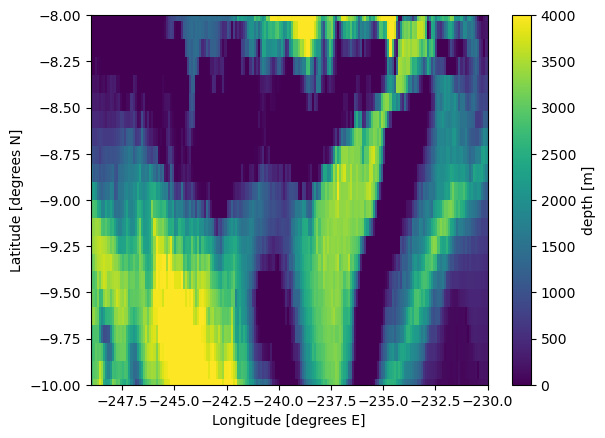

In [12]:
plt.pcolormesh(expt.bathymetry.lon, expt.bathymetry.lat, expt.bathymetry.depth[0, :, :], shading='auto',vmax=4000)
plt.colorbar(label = 'depth [m]')
plt.xlabel('Longitude [degrees E]')
plt.ylabel('Latitude [degrees N]');

plt.ylim(-10,-8)
#plt.xlim(-233.5,-230)

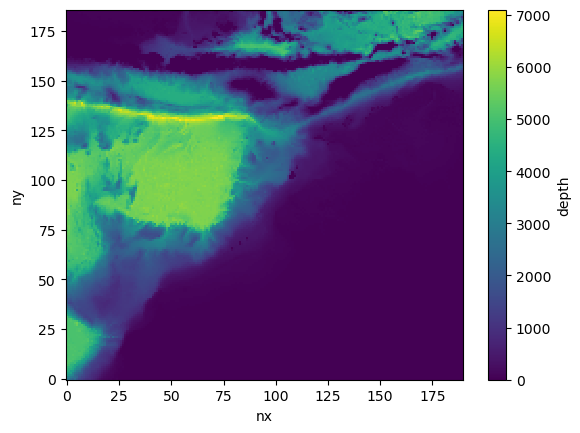

In [16]:
bath=xr.open_dataset('/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/bathymetry_mod.nc')
bath.depth.plot()

In [17]:
ocean_varnames = {"time": "time",
              "yh": "yh",
              "xh": "xh",
              "xq": "xq",
              "yq": "yq",
              "zl": "zl",
            "z_l": "z_l",
              "eta": "zos",
              "u": "uo",
              "v": "vo",
              "tracers": {"salt": "so", "temp": "thetao","no3":"no3","fe":"fe","o2":"o2","zoo":"zoo","phy":"phy","det":"det","caco3":"caco3","alk":"alk","caco3_sediment":"caco3_sediment","det_sediment":"det_sediment","pchl":"pchl", "phyfe":"phyfe", "zoofe":"zoofe", "detfe":"detfe", "dicp":"dicp", "dicr":"dicr","dic":"dic","detbury":"detbury","caco3bury":"caco3bury","detfe_sediment":"detfe_sediment"}
              }


bgc_varnames = {
              "no3":"no3","fe":"fe","o2":"o2","zoo":"zoo","phy":"phy","det":"det","caco3":"caco3","alk":"alk","caco3_sediment":"caco3_sediment","det_sediment":"det_sediment","pchl":"pchl", "phyfe":"phyfe", "zoofe":"zoofe", "detfe":"detfe", "dicp":"dicp", "dicr":"dicr","dic":"dic","detbury":"detbury","caco3bury":"caco3bury","detfe_sediment":"detfe_sediment"
              }

In [18]:
    # add tidal forcing for domain if wanted
setup_tides=True
if setup_tides:
        tidal_dir = Path('/g/data/nm03/TPXO/') 
        expt.setup_boundary_tides(
            tpxo_elevation_filepath='/g/data/nm03/TPXO/h_tpxo9.v1.nc',
            tpxo_velocity_filepath='/g/data/nm03/TPXO/u_tpxo9.v1.nc',
            tidal_constituents = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1", "MM", "MF"], 
            )

    
    



INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Creating Regridder


Processing north boundary...

INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to zamp_segment_001
INFO:regional_mom6.regridding:Adding perpendicular dimension to zphase_segment_001
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotat

Done
Processing south boundary...

INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to uamp_segment_002
INFO:regional_mom6.regridding:Adding perpendicular dimension to vamp_segment_002
INFO:regional_mom6.regridding:Adding perpendic

Done
Processing east boundary...

INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to uamp_segment_003
INFO:regional_mom6.regridding:Adding perpendicular dimension to vamp_segment_003
INFO:regional_mom6.regridding:Adding perpendic

Done
Processing west boundary...

INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding perpendicular dimension to uamp_segment_004
INFO:regional_mom6.regridding:Adding perpendicular dimension to vamp_segment_004
INFO:regional_mom6.regridding:Adding perpendic

Done


In [19]:
# do the regridding  
tmp_dir="/g/data/nm03/ee8016/NWshelf_01_IAF/"

if setup_regridded:
    # Set up the initial condition
    expt.setup_initial_condition(
        tmp_dir + "/ic_unprocessed.nc", # directory where the unprocessed initial condition is stored, as defined earlier
        ocean_varnames,
            arakawa_grid="C"
        )
    print('opening_to_edit')
    ds = xr.open_dataset(input_dir+'init_tracers.nc')
    #remaning dimentions
    ds = ds.rename({'nx': 'GRID_X_T','ny': 'GRID_Y_T', "zl": "ZT"})
    #adding correct values
    ds['GRID_X_T'] =ds.xh.values[0, 0:]#getting values for lat and lons
    ds['GRID_Y_T'] =ds.yh.values[0:, 0]
    #adding a time dimention 
    ds = ds.expand_dims({"time":1})
    ds = ds.assign_coords(time=("time", [0.0]))
    
   #changing fillvalue
    encoding = {var_name: {"_FillValue": -1e20} for var_name in ds.data_vars}
    
    ds.to_netcdf(input_dir+'init_tracers_modified.nc',encoding=encoding)



INFO:regional_mom6.utils:Units for eta did not need to be converted
INFO:regional_mom6.utils:Units for temp did not need to be converted


Applying Arakawa C grid variable mapping, which is u-velocity on xq, yh; v-velocity on xh, yq; and tracers on xh, yh.


INFO:regional_mom6.regridding:Getting t points..
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder


Setting up Initial Conditions
Regridding Velocities... 

INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Getting u points..
INFO:regional_mom6.regridding:Getting v points..


Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

opening_to_edit


In [20]:
tmp_dir="/g/data/nm03/ee8016/NWshelf_01_IAF/"

for i in range(1, 5):  # 1 to 4
    filename = f"{input_dir}forcing_obc_segment_{i:03d}.nc"
    if os.path.exists(filename):
        os.remove(filename)
        print(f"Deleted {filename}")
    else:
        print(f"{filename} does not exist")

import glob
import os

files = glob.glob(input_dir + '*_obc_segment.nc')
if files:
    for f in files:
        os.remove(f)
    print(f"Deleted {len(files)} file(s)")
    
if setup_regridded:

    #Set up the four boundary conditions.
    expt.setup_ocean_state_boundaries(
       Path(tmp_dir),
       ocean_varnames,
       arakawa_grid = "C",
        bgc_tracer_names=bgc_varnames,
        time_units="months",
       )
 

INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder


Deleted /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/forcing_obc_segment_001.nc
Deleted /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/forcing_obc_segment_002.nc
Deleted /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/forcing_obc_segment_003.nc
Deleted /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/forcing_obc_segment_004.nc
Deleted 20 file(s)
Processing north boundary velocity & tracers...Applying Arakawa C grid variable mapping, which is u-velocity on xq, yh; v-velocity on xh, yq; and tracers on xh, yh.
AFTER OPEN: [42383.5 42413.5 42443.5]


INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in no3_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with in

BEFORE IF: [42383.5 42413.5 42443.5]
raw_times[:3]: [42383.5 42413.5 42443.5]
times after subtract[:3]: [ 0. 30. 60.]
final time attrs: {'calendar': 'gregorian', 'units': 'days since 2016-01-15 00:00:00'}
final time values[:3]: [ 0. 30. 60.]


INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to zoofe_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in detfe_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to detfe_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in dicp_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to dicp_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in dicr_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to dicr_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordi

...

Done.
Processing west boundary velocity & tracers...Applying Arakawa C grid variable mapping, which is u-velocity on xq, yh; v-velocity on xh, yq; and tracers on xh, yh.
AFTER OPEN: [42383.5 42413.5 42443.5]


INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in no3_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with in

BEFORE IF: [42383.5 42413.5 42443.5]
raw_times[:3]: [42383.5 42413.5 42443.5]
times after subtract[:3]: [ 0. 30. 60.]
final time attrs: {'calendar': 'gregorian', 'units': 'days since 2016-01-15 00:00:00'}
final time values[:3]: [ 0. 30. 60.]


INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to zoofe_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in detfe_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to detfe_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in dicp_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to dicp_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in dicr_segment_004
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to dicr_segment_004
INFO:regional_mom6.regridding:Renaming vertical coordi

Done.
Saved BGC tracer no3 to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/no3_obc_segment.nc
Saved BGC tracer fe to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/fe_obc_segment.nc
Saved BGC tracer o2 to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/o2_obc_segment.nc
Saved BGC tracer zoo to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/zoo_obc_segment.nc
Saved BGC tracer phy to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/phy_obc_segment.nc
Saved BGC tracer det to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/det_obc_segment.nc
Saved BGC tracer caco3 to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/caco3_obc_segment.nc
Saved BGC tracer alk to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/alk_obc_segment.nc
Saved BGC tracer caco3_sediment to file /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/caco3_sediment_obc_segment.nc
Saved BGC tracer d

In [21]:
expt.run_FRE_tools(layout = (10, 10)) 


Running GFDL's FRE Tools. The following information is all printed by the FRE tools themselves
NOTE from make_solo_mosaic: there are 0 contacts (align-contact)
congradulation: You have successfully run make_solo_mosaic
OUTPUT FROM MAKE SOLO MOSAIC:

CompletedProcess(args='/g/data/ik11/mom6_tools/tools/make_solo_mosaic/make_solo_mosaic --num_tiles 1 --dir . --mosaic_name ocean_mosaic --tile_file hgrid.nc', returncode=0)


cp: './ocean_mosaic.nc' and 'ocean_mosaic.nc' are the same file
cp: './hgrid.nc' and 'hgrid.nc' are the same file


cp ./hgrid.nc hgrid.nc 

NOTE from make_coupler_mosaic: the ocean land/sea mask will be determined by field depth from file bathymetry.nc
mosaic_file is grid_spec.nc

***** Congratulation! You have successfully run make_quick_mosaic
OUTPUT FROM QUICK MOSAIC:

CompletedProcess(args='/g/data/ik11/mom6_tools/tools/make_quick_mosaic/make_quick_mosaic --input_mosaic ocean_mosaic.nc --mosaic_name grid_spec --ocean_topog bathymetry.nc', returncode=0)

 ===>NOTE from check_mask: when layout is specified, min_pe and max_pe is set to layout(1)*layout(2)=100

 ===>NOTE from check_mask: Below is the list of command line arguments.

grid_file = ocean_mosaic.nc
topog_file = bathymetry.nc
min_pe = 100
max_pe = 100
layout = 10, 10
halo = 4
sea_level = 0
show_valid_only is not set
nobc = 0

 ===>NOTE from check_mask: End of command line arguments.

 ===>NOTE from check_mask: the grid file is version 2 (mosaic grid) grid which contains field gridfiles

==>NOTE from get_boundary_type: x_boundary_type is 

In [22]:
        

expt.setup_run_directory(surface_forcing = "jra", using_payu = True, with_tides=True)

    
    
    

Could not find premade run directories at  /home/156/ee8016/rmom6/regional-mom6-fixbgc/regional-mom6/regional_mom6/demos/premade_run_directories
Perhaps the package was imported directly rather than installed with conda. Checking if this is the case... Found run files. Continuing...
Mask table mask_table.18.10x10 read. Using this to infer the cpu layout (10, 10), total masked out cells 18, and total number of CPUs 82.
Deleting indexed OBC keys from MOM_input_dict in case we have a different number of segments
Changed NJGLOBAL from 171 to 186in MOM_layout!
Changed MASKTABLE from mask_table.21.10x10 to mask_table.18.10x10in MOM_layout!


In [23]:
! python /g/data/vk83/apps/om3-scripts/wombat_ic_generation/regrid_forcing.py --forcing-filename=/g/data/ik11/inputs/WOMBAT/CESM-MIMI_1980-2015_CAM4-6MEAN_MonthlyDep_Hamiltonetal2020_clim.nc --hgrid-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/hgrid.nc --output-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/dust_DS.nc 


/g/data/vk83/apps/om3-scripts/scripts_common.py:127: UserWarning: /g/data/vk83/apps/om3-scripts/wombat_ic_generation/regrid_forcing.py not under git version control! Add your file to a repository before generating any production output.
  warn(
/g/data/vk83/apps/om3-scripts/wombat_ic_generation/regrid_forcing.py:168: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  forcing_src = xr.open_dataset(forcing_filename).compute()
/opt/conda/analysis3-26.01/lib/python3.11/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


In [24]:
! python3 /home/156/ee8016/libraries/om3-scripts/mesh_generation/generate_mesh.py --grid-type=mom --grid-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/hgrid.nc --mesh-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/access-rom3-ESMFmesh.nc --mask-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/ocean_mask.nc --wrap-lons

In [25]:
! python3 /home/156/ee8016/libraries/om3-scripts/mesh_generation/generate_mesh.py --grid-type=mom --grid-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/hgrid.nc --mesh-filename=/scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/access-rom3-nomask-ESMFmesh.nc --wrap-lons

In [27]:
! ls  /scratch/nm03/ee8016/regional_mom6_configs/NWshelf_01_IAF/

access-rom3-ESMFmesh.nc
access-rom3-nomask-ESMFmesh.nc
alk_obc_segment.nc
atmos_mosaic_tile1Xland_mosaic_tile1.nc
atmos_mosaic_tile1Xocean_mosaic_tile1.nc
bathymetry.nc
bathymetry_mod.nc
bathymetry_original.nc
bathymetry_unfinished.nc
caco3_obc_segment.nc
caco3_sediment_obc_segment.nc
caco3bury_obc_segment.nc
det_obc_segment.nc
det_sediment_obc_segment.nc
detbury_obc_segment.nc
detfe_obc_segment.nc
detfe_sediment_obc_segment.nc
dic_obc_segment.nc
dicp_obc_segment.nc
dicr_obc_segment.nc
dust_DS.nc
fe_obc_segment.nc
five_dye_input.nc
forcing
forcing_obc_segment_001.nc
forcing_obc_segment_002.nc
forcing_obc_segment_003.nc
forcing_obc_segment_004.nc
grid_spec.nc
hgrid.nc
init_eta.nc
init_tracers.nc
init_tracers_modified.nc
init_vel.nc
land_mask.nc
land_mosaic_tile1Xocean_mosaic_tile1.nc
mask_table.18.10x10
no3_obc_segment.nc
o2_obc_segment.nc
ocean_mask.nc
ocean_mosaic.nc
pchl_obc_segment.nc
phy_obc_segment.nc
phyfe_obc_segment.nc
rundir
tu_segment_001.nc
tu_segment_002.nc
tu_segment_003.n